In [14]:
!pip install deepface transformers torch librosa soundfile opencv-python matplotlib pillow

In [15]:
from deepface import DeepFace
from transformers import pipeline
from google.colab import files
from collections import Counter
from PIL import Image
import matplotlib.pyplot as plt

In [16]:
# Text Emotion Model
text_classifier = pipeline(
    "text-classification",
    model="j-hartmann/emotion-english-distilroberta-base",
    top_k=1
)

# Speech Emotion Model
speech_classifier = pipeline(
    task="audio-classification",
    model="ehcalabres/wav2vec2-lg-xlsr-en-speech-emotion-recognition"
)

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/422 [00:00<?, ?it/s]

[transformers] Wav2Vec2ForSequenceClassification LOAD REPORT from: ehcalabres/wav2vec2-lg-xlsr-en-speech-emotion-recognition
Key                      | Status     | 
-------------------------+------------+-
classifier.output.bias   | UNEXPECTED | 
classifier.dense.bias    | UNEXPECTED | 
classifier.dense.weight  | UNEXPECTED | 
classifier.output.weight | UNEXPECTED | 
classifier.bias          | MISSING    | 
projector.weight         | MISSING    | 
projector.bias           | MISSING    | 
classifier.weight        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [17]:
def detect_face_emotion():

    print("Upload Face Image")

    uploaded = files.upload()

    image_path = list(uploaded.keys())[0]

    img = Image.open(image_path)

    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

    result = DeepFace.analyze(
        img_path=image_path,
        actions=['emotion'],
        enforce_detection=False
    )

    emotion = result[0]['dominant_emotion']

    print("Face Emotion :", emotion)

    return emotion

In [18]:
def detect_text_emotion():

    text = input("Enter Text : ")

    result = text_classifier(text)

    emotion = result[0][0]['label']

    print("Text Emotion :", emotion)

    return emotion

In [19]:
def detect_speech_emotion():

    print("Upload Audio (.wav)")

    uploaded = files.upload()

    audio_path = list(uploaded.keys())[0]

    result = speech_classifier(audio_path)

    emotion = result[0]['label']

    print("Speech Emotion :", emotion)

    return emotion

In [20]:
emotion_map = {

    "joy":"happy",

    "happiness":"happy",

    "sadness":"sad",

    "anger":"angry",

    "fearful":"fear",

    "surprised":"surprise",

    "neutral":"neutral"

}

In [21]:
recommendations = {

"happy":"😊 Keep smiling! Have a wonderful day.",

"sad":"❤️ Take some rest and talk to someone close.",

"angry":"😌 Take deep breaths and relax.",

"fear":"🌸 Stay calm. Everything will be okay.",

"surprise":"🎉 Hope it's a pleasant surprise!",

"neutral":"🙂 Stay focused and have a productive day."

}

Upload Face Image


Saving img4.jpg to img4 (1).jpg


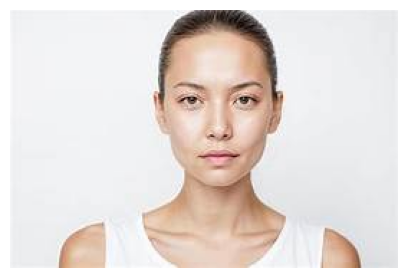

Face Emotion : neutral
Enter Text : i have place my dream company.
Text Emotion : joy
Upload Audio (.wav)


Saving WhatsApp Ptt 2026-07-07 at 7.57.06 PM.ogg to WhatsApp Ptt 2026-07-07 at 7.57.06 PM (2).ogg
Speech Emotion : calm

Face Emotion : neutral
Text Emotion : happy
Speech Emotion : calm
Final Emotion : neutral
Recommendation :
🙂 Stay focused and have a productive day.


In [23]:
face_emotion = detect_face_emotion()

text_emotion = detect_text_emotion()

speech_emotion = detect_speech_emotion()

face_emotion = emotion_map.get(face_emotion.lower(), face_emotion.lower())

text_emotion = emotion_map.get(text_emotion.lower(), text_emotion.lower())

speech_emotion = emotion_map.get(speech_emotion.lower(), speech_emotion.lower())

votes = [

    face_emotion,

    text_emotion,

    speech_emotion

]

final_emotion = Counter(votes).most_common(1)[0][0]

print("\n==========================")

print("Face Emotion :", face_emotion)

print("Text Emotion :", text_emotion)

print("Speech Emotion :", speech_emotion)

print("==========================")

print("Final Emotion :", final_emotion)

print("==========================")

print("Recommendation :")

print(recommendations.get(final_emotion))